In [5]:
import pandas as pd
df = pd.read_csv("shopping_trends.csv")
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,...,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases,unnamed_col,record_timestamp,index_copy,notes
0,1072,61.0,Male,Hat,Accessories,81,Pennsylvania,M,Beige,Summer,...,Express,Yes,Yes,46,Credit Card,Monthly,NaN,2024-01-01 00:00:00,0,NaN
1,1201,27.0,Male,Coat,Outerwear,22,Connecticut,XL,Black,Winter,...,Store Pickup,Yes,Yes,7,PayPal,Weekly,NaN,2024-01-01 00:00:00,1,NaN
2,2719,22.0,Female,Shorts,Clothing,90,Virginia,M,Peach,Winter,...,Next Day Air,NaN,No,10,Venmo,Bi-Weekly,NaN,2024-01-01 00:00:00,2,NaN
3,1290,35.0,Male,Jacket,Outerwear,24,New Hampshire,M,Red,Fall,...,Next Day Air,Yes,Yes,10,PayPal,Weekly,NaN,2024-01-01 00:00:00,3,NaN
4,3688,34.0,Female,Shirt,Clothing,44,Arkansas,L,Lavender,Summer,...,Next Day Air,No,No,28,Bank Transfer,Every 3 Months,NaN,2024-01-01 00:00:00,4,NaN


In [6]:
df=df.drop(columns=["record_timestamp","unnamed_col","index_copy","notes"])

In [7]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1072,61.0,Male,Hat,Accessories,81,Pennsylvania,M,Beige,Summer,2.6,No,Cash,Express,Yes,Yes,46,Credit Card,Monthly
1,1201,27.0,Male,Coat,Outerwear,22,Connecticut,XL,Black,Winter,4.4,No,Bank Transfer,Store Pickup,Yes,Yes,7,PayPal,Weekly
2,2719,22.0,Female,Shorts,Clothing,90,Virginia,M,Peach,Winter,4.9,No,Credit Card,Next Day Air,NaN,No,10,Venmo,Bi-Weekly
3,1290,35.0,Male,Jacket,Outerwear,24,New Hampshire,M,Red,Fall,2.9,No,Debit Card,Next Day Air,Yes,Yes,10,PayPal,Weekly
4,3688,34.0,Female,Shirt,Clothing,44,Arkansas,L,Lavender,Summer,2.9,No,PayPal,Next Day Air,No,No,28,Bank Transfer,Every 3 Months


In [8]:
df.dtypes

Customer ID                   int64
Age                         float64
Gender                          str
Item Purchased                  str
Category                        str
Purchase Amount (USD)         int64
Location                        str
Size                            str
Color                           str
Season                          str
Review Rating               float64
Subscription Status             str
Payment Method                  str
Shipping Type                   str
Discount Applied                str
Promo Code Used                 str
Previous Purchases            int64
Preferred Payment Method        str
Frequency of Purchases          str
dtype: object

In [9]:
df.duplicated().sum()

np.int64(35)

In [10]:
df=df.drop_duplicates()
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1072,61.0,Male,Hat,Accessories,81,Pennsylvania,M,Beige,Summer,2.6,No,Cash,Express,Yes,Yes,46,Credit Card,Monthly
1,1201,27.0,Male,Coat,Outerwear,22,Connecticut,XL,Black,Winter,4.4,No,Bank Transfer,Store Pickup,Yes,Yes,7,PayPal,Weekly
2,2719,22.0,Female,Shorts,Clothing,90,Virginia,M,Peach,Winter,4.9,No,Credit Card,Next Day Air,NaN,No,10,Venmo,Bi-Weekly
3,1290,35.0,Male,Jacket,Outerwear,24,New Hampshire,M,Red,Fall,2.9,No,Debit Card,Next Day Air,Yes,Yes,10,PayPal,Weekly
4,3688,34.0,Female,Shirt,Clothing,44,Arkansas,L,Lavender,Summer,2.9,No,PayPal,Next Day Air,No,No,28,Bank Transfer,Every 3 Months


In [11]:
df.isnull().sum()

Customer ID                   0
Age                         204
Gender                      169
Item Purchased                0
Category                      0
Purchase Amount (USD)         0
Location                    250
Size                          0
Color                         0
Season                        0
Review Rating               326
Subscription Status         165
Payment Method                0
Shipping Type               181
Discount Applied            274
Promo Code Used               0
Previous Purchases            0
Preferred Payment Method      0
Frequency of Purchases        0
dtype: int64

In [12]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3982.000000,3778.000000,3982.000000,3656.000000,3982.000000
mean,1952.300352,46.606141,59.610748,3.746335,25.347313
std,1125.128474,51.362258,23.802707,0.718170,14.445827
min,1.000000,18.000000,-1.000000,2.500000,1.000000
25%,979.250000,31.000000,38.000000,3.100000,13.000000
50%,1951.500000,44.000000,60.000000,3.700000,25.000000
75%,2924.750000,57.000000,80.750000,4.400000,38.000000
max,3900.000000,999.000000,100.000000,5.000000,50.000000


In [13]:
df["Age"]=df["Age"].replace(999, int(df[df["Age"] != 999]["Age"].mean()))
df["Age"]=df["Age"].replace(-1, int(df[df["Age"] != -1]["Age"].mean()))

In [14]:
df["Purchase Amount (USD)"]=df["Purchase Amount (USD)"].replace(-1, int(df[df["Purchase Amount (USD)"] != -1]["Purchase Amount (USD)"].mean()))


In [15]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3982.000000,3778.000000,3982.000000,3656.000000,3982.000000
mean,1952.300352,44.078348,59.731291,3.746335,25.347313
std,1125.128474,15.171954,23.646833,0.718170,14.445827
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,979.250000,31.000000,39.000000,3.100000,13.000000
50%,1951.500000,44.000000,60.000000,3.700000,25.000000
75%,2924.750000,57.000000,80.750000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [16]:
df.describe(include="str")

,Gender,Item Purchased,Category,Location,Size,Color,Season,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Preferred Payment Method,Frequency of Purchases
count,3813,3982,3982,3732,3982,3982,3982,3817,3982,3801,3708,3982,3982,3982
unique,4,25,4,50,4,25,4,2,6,6,2,2,6,7
top,Male,Pants,Clothing,California,M,Olive,Spring,No,Credit Card,Free Shipping,No,No,PayPal,Every 3 Months
freq,2199,177,1781,95,1790,182,1020,2786,706,659,2113,2272,687,599


In [17]:
df["Gender"]=df["Gender"].replace("male","Male")
df["Gender"]=df["Gender"].replace("female","Female")
df["Gender"]=df["Gender"].replace("FEMALE","Female")
df.describe(include="str")

,Gender,Item Purchased,Category,Location,Size,Color,Season,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Preferred Payment Method,Frequency of Purchases
count,3813,3982,3982,3732,3982,3982,3982,3817,3982,3801,3708,3982,3982,3982
unique,2,25,4,50,4,25,4,2,6,6,2,2,6,7
top,Male,Pants,Clothing,California,M,Olive,Spring,No,Credit Card,Free Shipping,No,No,PayPal,Every 3 Months
freq,2590,177,1781,95,1790,182,1020,2786,706,659,2113,2272,687,599


In [18]:
df["Age"]=df["Age"].fillna(df["Age"].mean())
df["Review Rating"]=df["Review Rating"].fillna(df["Review Rating"].mean())
df["Gender"]=df["Gender"].fillna(df["Gender"].mode().item())
df["Location"]=df["Location"].fillna(df["Location"].mode().item())
df["Subscription Status"]=df["Subscription Status"].fillna(df["Subscription Status"].mode().item())
df["Shipping Type"]=df["Shipping Type"].fillna(df["Shipping Type"].mode().item())
df["Discount Applied"]=df["Discount Applied"].fillna(df["Discount Applied"].mode().item())
df.isnull().sum()

Customer ID                 0
Age                         0
Gender                      0
Item Purchased              0
Category                    0
Purchase Amount (USD)       0
Location                    0
Size                        0
Color                       0
Season                      0
Review Rating               0
Subscription Status         0
Payment Method              0
Shipping Type               0
Discount Applied            0
Promo Code Used             0
Previous Purchases          0
Preferred Payment Method    0
Frequency of Purchases      0
dtype: int64

In [19]:
import matplotlib.pyplot as plt
import streamlit as st

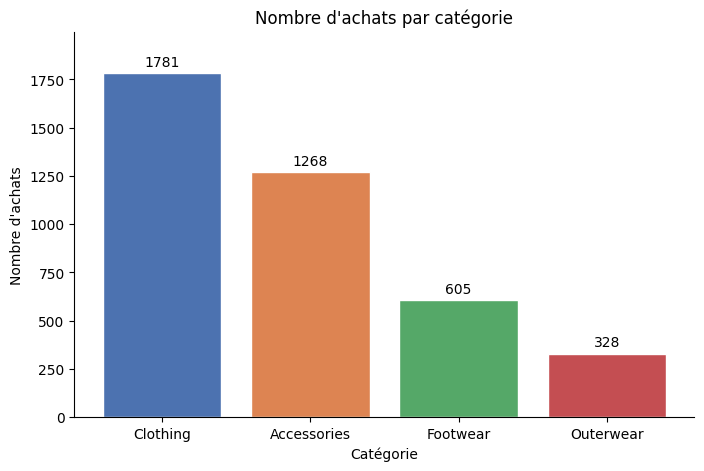

In [35]:
cat_counts = df['Category'].value_counts()


fig, ax = plt.subplots(figsize=(8, 5))


colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
bars = ax.bar(cat_counts.index, cat_counts.values, color=colors, edgecolor='white')


ax.bar_label(bars, padding=3)

ax.set_title("Nombre d'achats par catégorie")
ax.set_xlabel('Catégorie')
ax.set_ylabel("Nombre d'achats")


ax.spines[['top', 'right']].set_visible(False)
ax.set_ylim(0, cat_counts.max() * 1.12)

plt.show()

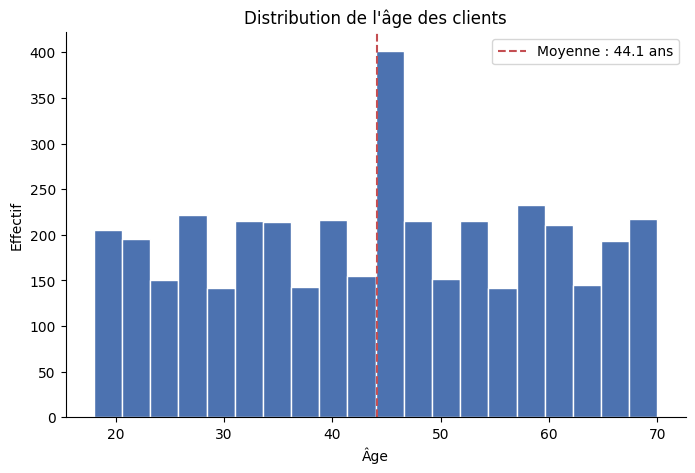

In [34]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(df['Age'], bins=20, color='#4C72B0', edgecolor='white')

ax.axvline(df['Age'].mean(), color='#C44E52', linestyle='--', label=f"Moyenne : {df['Age'].mean():.1f} ans")

ax.set_title("Distribution de l'âge des clients")
ax.set_xlabel('Âge')
ax.set_ylabel('Effectif')

ax.spines[['top', 'right']].set_visible(False)

ax.legend()

plt.show()

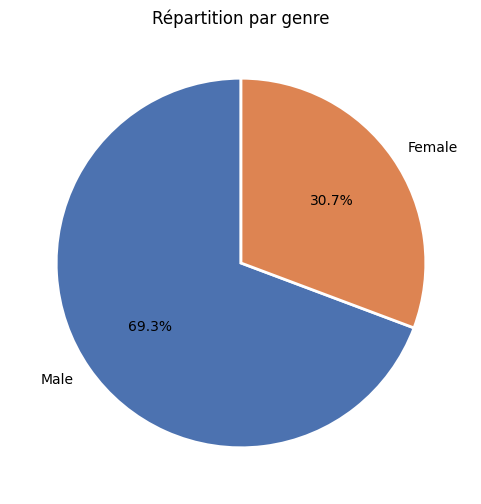

In [33]:
fig, ax = plt.subplots(figsize=(6, 6))

gender_counts = df['Gender'].value_counts()

ax.pie(
    gender_counts.values,
    labels=gender_counts.index,
    autopct='%1.1f%%',
    colors=['#4C72B0', '#DD8452'],
    startangle=90,
    wedgeprops={'linewidth': 2, 'edgecolor': 'white'}
)

ax.set_title('Répartition par genre')

plt.show()

C:\Users\SBS\AppData\Local\Temp\ipykernel_1872\2415485873.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(season_data, labels=season_order, patch_artist=True, notch=False,


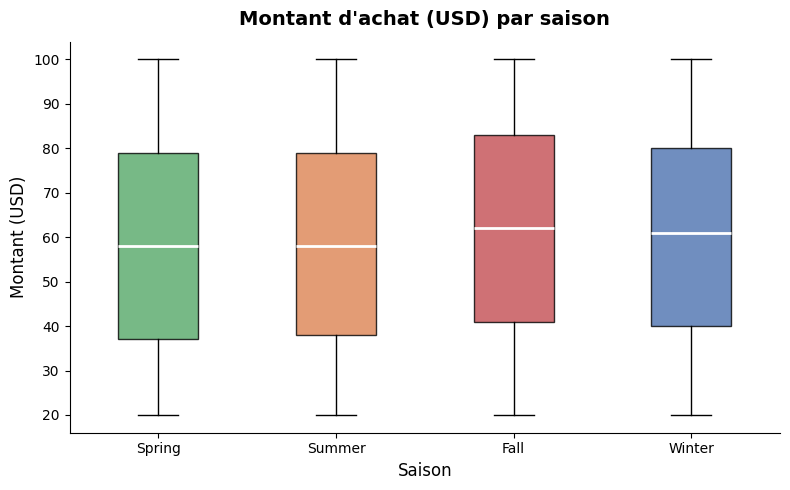

In [23]:
fig, ax = plt.subplots(figsize=(8, 5))
season_order = ['Spring', 'Summer', 'Fall', 'Winter']
season_data = [df[df['Season'] == s]['Purchase Amount (USD)'].dropna().values for s in season_order]
bp = ax.boxplot(season_data, labels=season_order, patch_artist=True, notch=False,
                medianprops={'color': 'white', 'linewidth': 2})
palette = ['#55A868', '#DD8452', '#C44E52', '#4C72B0']
for patch, color in zip(bp['boxes'], palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
ax.set_title("Montant d'achat (USD) par saison", fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Saison', fontsize=12)
ax.set_ylabel('Montant (USD)', fontsize=12)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

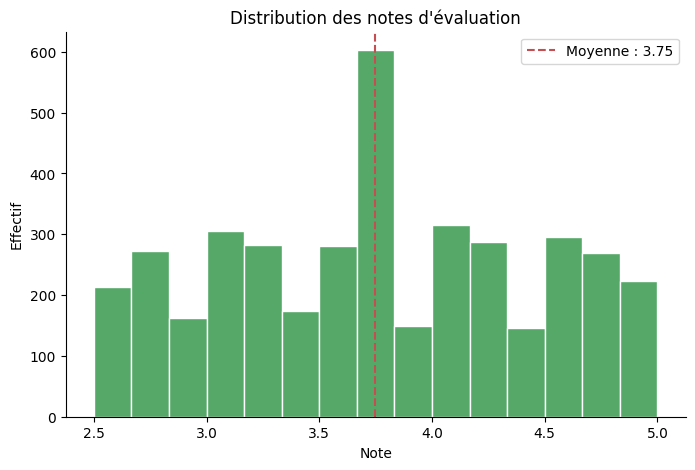

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(df['Review Rating'], bins=15, color='#55A868', edgecolor='white')

ax.axvline(df['Review Rating'].mean(), color='#C44E52', linestyle='--',
           label=f"Moyenne : {df['Review Rating'].mean():.2f}")

ax.set_title("Distribution des notes d'évaluation")
ax.set_xlabel('Note')
ax.set_ylabel('Effectif')

ax.spines[['top', 'right']].set_visible(False)

ax.legend()

plt.show()

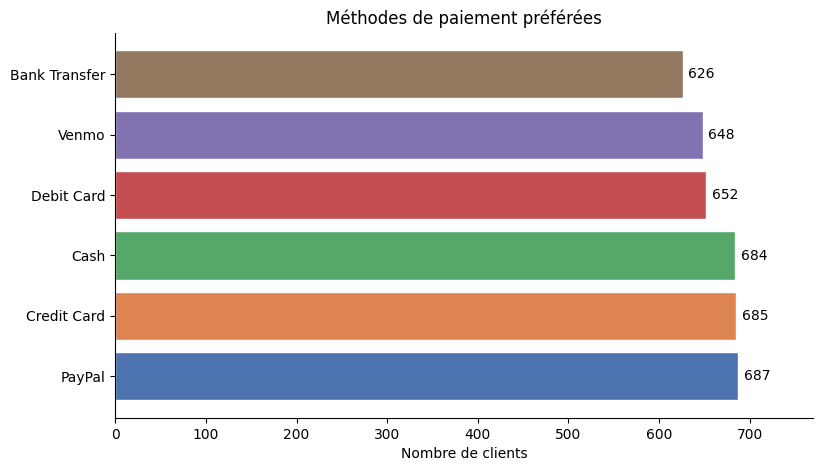

In [31]:
fig, ax = plt.subplots(figsize=(9, 5))

pay_counts = df['Preferred Payment Method'].value_counts()

colors_pay = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2', '#937860']
bars = ax.barh(pay_counts.index, pay_counts.values, color=colors_pay, edgecolor='white')

ax.bar_label(bars, padding=4)

ax.set_title('Méthodes de paiement préférées')
ax.set_xlabel('Nombre de clients')

ax.spines[['top', 'right']].set_visible(False)

ax.set_xlim(0, pay_counts.max() * 1.12)

plt.show()

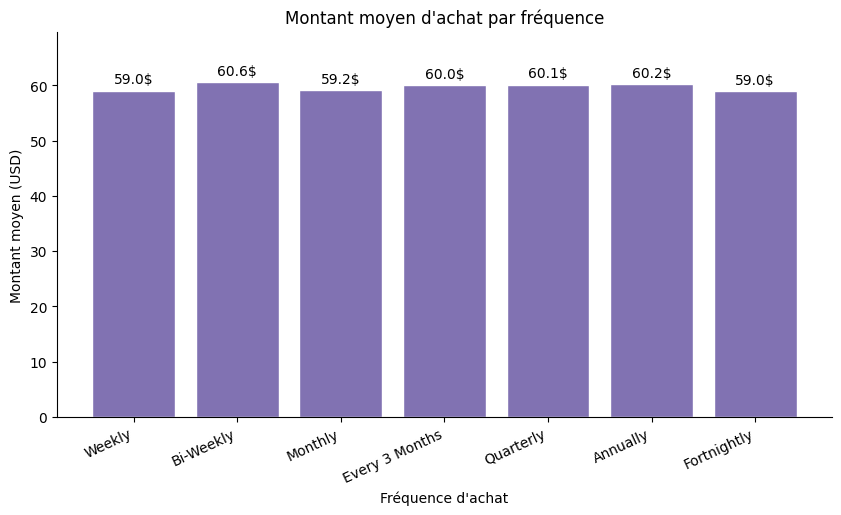

In [29]:
fig, ax = plt.subplots(figsize=(10, 5))

freq_order = ['Weekly', 'Bi-Weekly', 'Monthly', 'Every 3 Months', 'Quarterly', 'Annually', 'Fortnightly']
freq_order = [f for f in freq_order if f in df['Frequency of Purchases'].unique()]

freq_avg = df.groupby('Frequency of Purchases')['Purchase Amount (USD)'].mean().reindex(freq_order).dropna()

bars = ax.bar(freq_avg.index, freq_avg.values, color='#8172B2', edgecolor='white')

ax.bar_label(bars, fmt='%.1f$', padding=3)

ax.set_title("Montant moyen d'achat par fréquence")
ax.set_xlabel("Fréquence d'achat")
ax.set_ylabel('Montant moyen (USD)')

ax.spines[['top', 'right']].set_visible(False)

ax.set_ylim(0, freq_avg.max() * 1.15)

plt.xticks(rotation=25, ha='right')

plt.show()